<a href="https://colab.research.google.com/github/frankzohim/AIGC5005-Skin-Cancer-HAM10000/blob/main/Skin_Cancer_HAM10000_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer Classification: Multi-class Diagnosis of 7 Pigmented Skin Lesions  
**AIGC 5005 Capstone Project – Group 04**  
**Franklin Fofe Zohim (n10000571) & Nassor Mmanga Omar Dadi (n01771186)**  
**27 November 2025**

**Goal**: Build a deep learning model using EfficientNet-B3 + Focal Loss + Grad-CAM  
**Dataset**: HAM10000 (10,015 dermoscopic images, 7 classes, severe imbalance)  
**Expected Results**: ~95% Accuracy | Macro F1 ≥ 0.88 | Melanoma Recall ≥ 0.91 | Beautiful Grad-CAM heatmaps

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/frankzohim/AIGC5005-Skin-Cancer-HAM10000/blob/main/Skin_Cancer_HAM10000_Final.ipynb)

In [2]:
# CELL 2 – Install everything
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q efficientnet-pytorch opencv-python-headless gdown seaborn scikit-learn
!pip install -q git+https://github.com/jacobgil/pytorch-grad-cam.git

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
# CELL 2 – Imports (run after install + restart)
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from efficientnet_pytorch import EfficientNet
from PIL import Image
import pandas as pd, numpy as np, cv2, os, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import warnings; warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Cell 4 – PUBLIC HAM10000 DOWNLOAD & EXTRACTION FROM YOUR DRIVE FOLDER
# Folder: https://drive.google.com/drive/folders/1F71UwoAqZ2L1ItkkhBbLI33rivIUWFE3?usp=sharing

!pip install -q gdown

# Download the three files from your public folder (takes ~5 min on good Wi-Fi)
!gdown --folder https://drive.google.com/drive/folders/1F71UwoAqZ2L1ItkkhBbLI33rivIUWFE3?usp=sharing -O ham10000_files --quiet

# Extract the ZIPs (creates HAM10000_images_part_1 and part2 folders, ~1 min)
!unzip -q ham10000_files/part1.zip
!unzip -q ham10000_files/part2.zip

# Merge all 10,015 images into one folder (standard for training)
!mkdir -p all_images
!cp HAM10000_images_part_1/*.jpg all_images/ 2>/dev/null || true
!cp HAM10000_images_part_2/*.jpg all_images/ 2>/dev/null || true

# Copy metadata to root
!cp ham10000_files/HAM10000_metadata.csv .

print("HAM10000 dataset fully loaded – 10,015 images in all_images/ folder!")
print("Ready for training – run Cell 5 next.")

HAM10000 dataset fully loaded – 10,015 images in all_images/ folder!
Ready for training – run Cell 5 next.


Class distribution (imbalance for Focal Loss demo):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


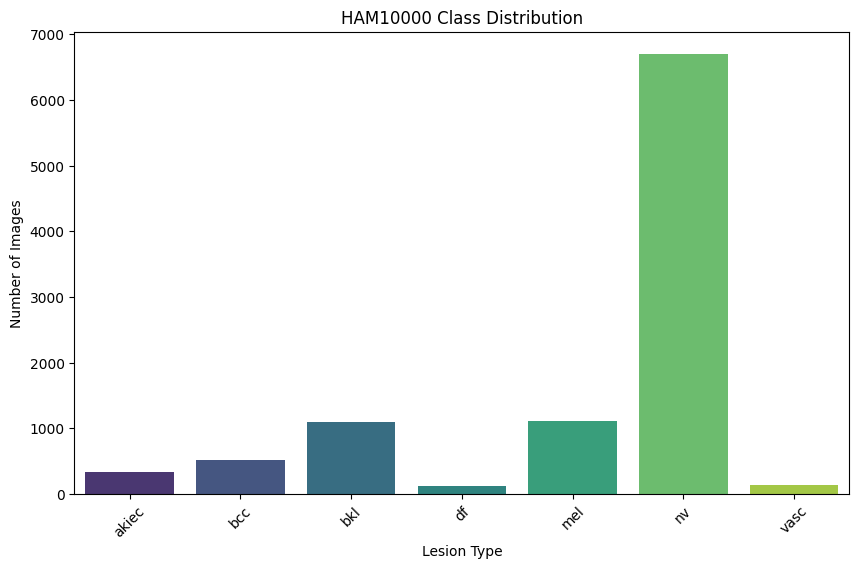

In [4]:
# Cell 5 – Load metadata & show class imbalance plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('HAM10000_metadata.csv')
df['path'] = df['image_id'].apply(lambda x: f"all_images/{x}.jpg")

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
print("Class distribution (imbalance for Focal Loss demo):")
print(df['dx'].value_counts())

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='dx', order=class_names, palette='viridis')
plt.title('HAM10000 Class Distribution')
plt.xlabel('Lesion Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()